In [ ]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Install missing libraries
!pip install evaluate -qq

# Transformers and datasets
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    T5ForConditionalGeneration,
    T5Tokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import evaluate

# LoRA and quantization
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training
)
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


## 1. Dataset Loading and Exploration

Loading the MultiNLI dataset which contains premise-hypothesis pairs across multiple genres with labels: entailment (0), neutral (1), contradiction (2)

In [ ]:
# Load MultiNLI dataset
print("Loading MultiNLI dataset from Hugging Face...")
dataset = load_dataset("nyu-mll/multi_nli")

print("\nDataset structure:")
print(dataset)

print("\nTrain set size:", len(dataset['train']))
print("Validation matched size:", len(dataset['validation_matched']))
print("Validation mismatched size:", len(dataset['validation_mismatched']))

# Display sample
print("Sample from training set:")
sample = dataset['train'][0]
for key, value in sample.items():
    print(f"{key:20s}: {value}")

Loading MultiNLI dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9832
    })
})

Train set size: 392702
Validation matched size: 9815
Validation mismatched size: 9832
Sample from training set:
promptID            : 31193
pairID              : 31193n
premise             : Conceptually cream skimming has two basic dimensions - product and g

Exploring genres in MultiNLI...

Genre distribution in training set:
telephone           :  83348 (21.22%)
government          :  77350 (19.70%)
travel              :  77350 (19.70%)
fiction             :  77348 (19.70%)
slate               :  77306 (19.69%)


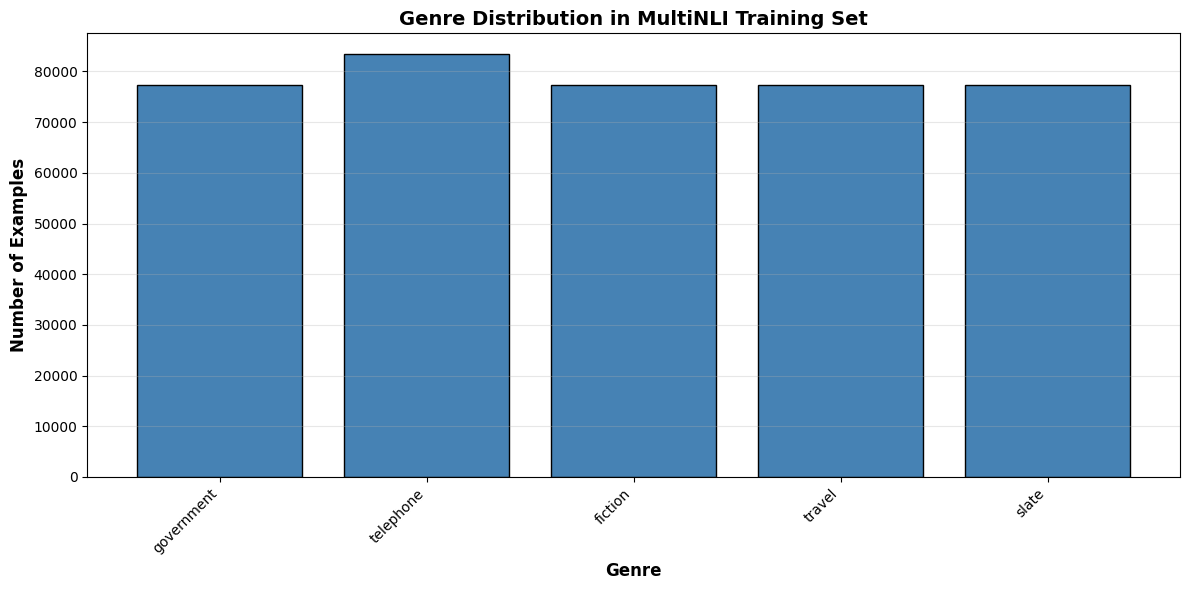

Label distribution in training set:
entailment          : 130899 (33.33%)
neutral             : 130900 (33.33%)
contradiction       : 130903 (33.33%)


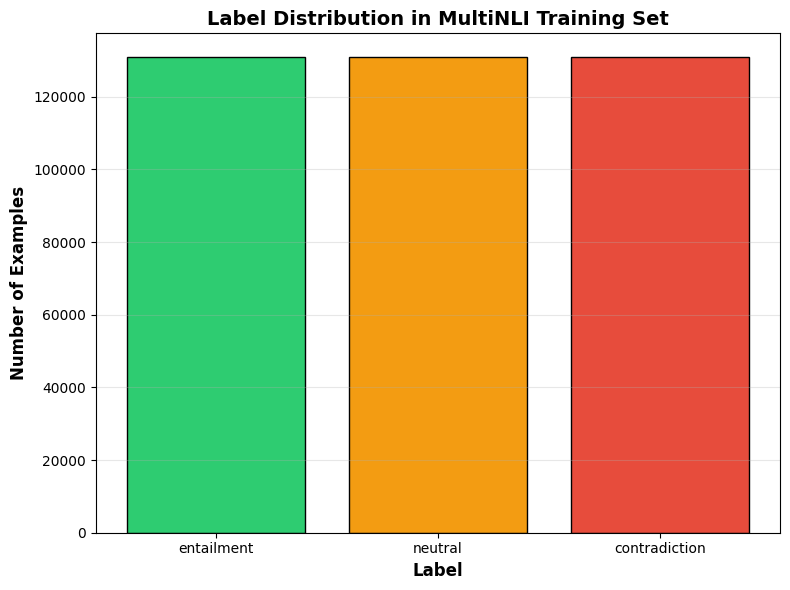

In [ ]:
# Explore genres in the dataset
print("Exploring genres in MultiNLI...")

# Extract genres from training set
train_genres = [example['genre'] for example in dataset['train']]
genre_counts = Counter(train_genres)

print("\nGenre distribution in training set:")
print("="*60)
for genre, count in sorted(genre_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{genre:20s}: {count:6d} ({count/len(train_genres)*100:.2f}%)")

# Visualize genre distribution
plt.figure(figsize=(12, 6))
genres = list(genre_counts.keys())
counts = list(genre_counts.values())
plt.bar(genres, counts, color='steelblue', edgecolor='black')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Number of Examples', fontsize=12, fontweight='bold')
plt.title('Genre Distribution in MultiNLI Training Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Label distribution
label_map = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
train_labels = [example['label'] for example in dataset['train']]
label_counts = Counter(train_labels)

print("Label distribution in training set:")
for label, count in sorted(label_counts.items()):
    print(f"{label_map[label]:20s}: {count:6d} ({count/len(train_labels)*100:.2f}%)")

# Visualize label distribution
plt.figure(figsize=(8, 6))
labels = [label_map[l] for l in sorted(label_counts.keys())]
counts = [label_counts[l] for l in sorted(label_counts.keys())]
plt.bar(labels, counts, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Examples', fontsize=12, fontweight='bold')
plt.title('Label Distribution in MultiNLI Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Data Preprocessing

Clean and prepare the data for training. Handle missing values, normalize text, and prepare for genre-split experiments.

In [ ]:
# Data cleaning and preprocessing
def preprocess_dataset(examples):
    """
    Clean and preprocess the dataset.
    - Remove entries with missing labels (label == -1)
    - Ensure premise and hypothesis are valid strings
    """
    # Filter out invalid labels
    valid_indices = [i for i, label in enumerate(examples['label']) if label != -1]

    return {
        'premise': [examples['premise'][i] for i in valid_indices],
        'hypothesis': [examples['hypothesis'][i] for i in valid_indices],
        'label': [examples['label'][i] for i in valid_indices],
        'genre': [examples['genre'][i] for i in valid_indices]
    }

# Check for missing labels before preprocessing
print("Checking data quality...")
train_invalid = sum(1 for ex in dataset['train'] if ex['label'] == -1)
val_matched_invalid = sum(1 for ex in dataset['validation_matched'] if ex['label'] == -1)
val_mismatched_invalid = sum(1 for ex in dataset['validation_mismatched'] if ex['label'] == -1)

print(f"Train invalid labels: {train_invalid}")
print(f"Validation matched invalid labels: {val_matched_invalid}")
print(f"Validation mismatched invalid labels: {val_mismatched_invalid}")

# Convert to pandas for easier preprocessing
train_df = pd.DataFrame(dataset['train'])
val_matched_df = pd.DataFrame(dataset['validation_matched'])
val_mismatched_df = pd.DataFrame(dataset['validation_mismatched'])

# Filter out invalid labels
print("\nFiltering invalid labels...")
train_df = train_df[train_df['label'] != -1].reset_index(drop=True)
val_matched_df = val_matched_df[val_matched_df['label'] != -1].reset_index(drop=True)
val_mismatched_df = val_mismatched_df[val_mismatched_df['label'] != -1].reset_index(drop=True)

print(f"After filtering - Train: {len(train_df)}, Val Matched: {len(val_matched_df)}, Val Mismatched: {len(val_mismatched_df)}")

# Check for null values
print("\nChecking for null values:")
print(f"Train nulls: {train_df.isnull().sum().sum()}")
print(f"Val matched nulls: {val_matched_df.isnull().sum().sum()}")
print(f"Val mismatched nulls: {val_mismatched_df.isnull().sum().sum()}")

Checking data quality...
Train invalid labels: 0
Validation matched invalid labels: 0
Validation mismatched invalid labels: 0

Filtering invalid labels...
After filtering - Train: 392702, Val Matched: 9815, Val Mismatched: 9832

Checking for null values:
Train nulls: 0
Val matched nulls: 0
Val mismatched nulls: 0


All genres: ['government', 'telephone', 'fiction', 'travel', 'slate']

SEEN GENRES (for training): ['fiction', 'slate', 'telephone']
UNSEEN GENRES (for testing): ['government', 'travel']

Dataset sizes after genre split:
Training (seen genres): 238002
Training (unseen genres - for reference): 154700

Validation Matched (seen): 5894
Validation Matched (unseen): 3921
Validation Mismatched (seen): 0
Validation Mismatched (unseen): 0


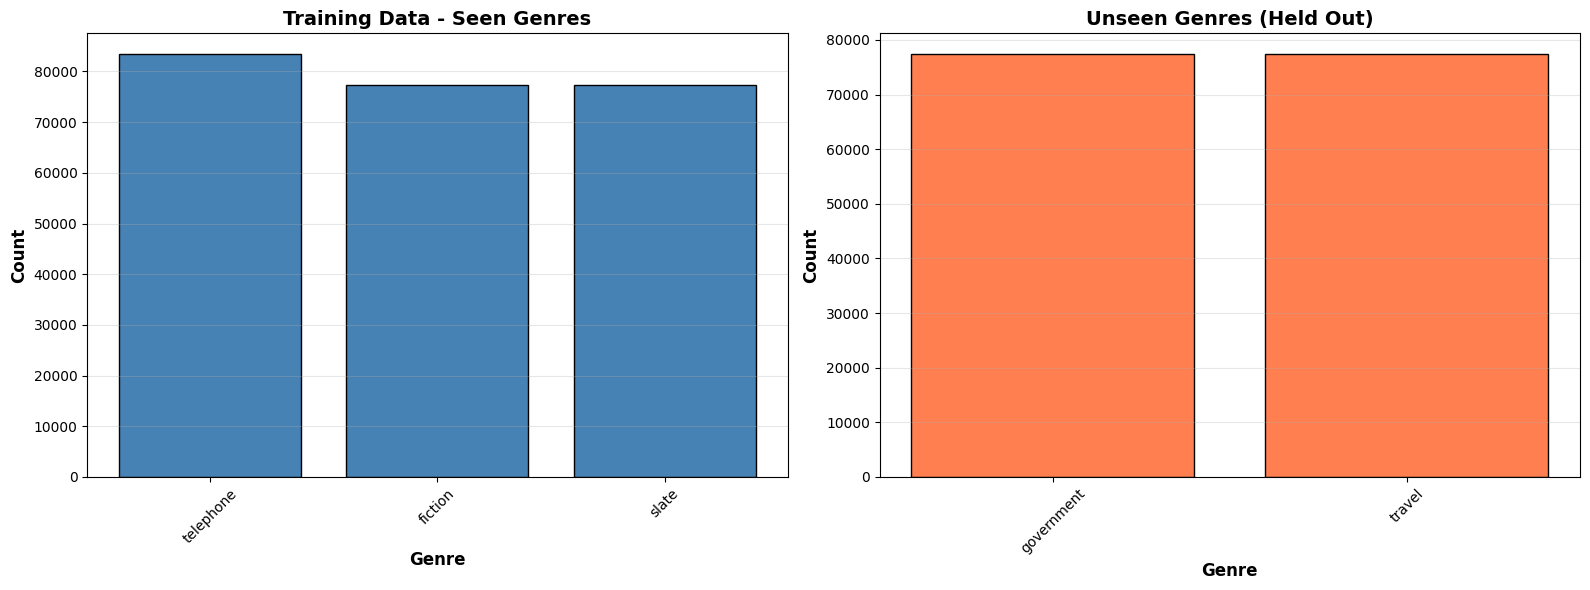

In [ ]:
# Define genre splits for domain generalization
all_genres = list(train_df['genre'].unique())
print(f"All genres: {all_genres}")

# Split genres into seen (for training) and unseen (for testing generalization)
# We'll use 70% of genres for training and 30% as unseen
np.random.seed(42)
np.random.shuffle(all_genres)

split_point = int(len(all_genres) * 0.7)
seen_genres = sorted(all_genres[:split_point])
unseen_genres = sorted(all_genres[split_point:])

print(f"\n{'='*60}")
print(f"SEEN GENRES (for training): {seen_genres}")
print(f"UNSEEN GENRES (for testing): {unseen_genres}")
print(f"{'='*60}")

# Create genre-split datasets
train_seen = train_df[train_df['genre'].isin(seen_genres)].reset_index(drop=True)
train_unseen = train_df[train_df['genre'].isin(unseen_genres)].reset_index(drop=True)  # For comparison only

# Validation splits
val_matched_seen = val_matched_df[val_matched_df['genre'].isin(seen_genres)].reset_index(drop=True)
val_matched_unseen = val_matched_df[val_matched_df['genre'].isin(unseen_genres)].reset_index(drop=True)
val_mismatched_seen = val_mismatched_df[val_mismatched_df['genre'].isin(seen_genres)].reset_index(drop=True)
val_mismatched_unseen = val_mismatched_df[val_mismatched_df['genre'].isin(unseen_genres)].reset_index(drop=True)

print(f"\nDataset sizes after genre split:")
print(f"Training (seen genres): {len(train_seen)}")
print(f"Training (unseen genres - for reference): {len(train_unseen)}")
print(f"\nValidation Matched (seen): {len(val_matched_seen)}")
print(f"Validation Matched (unseen): {len(val_matched_unseen)}")
print(f"Validation Mismatched (seen): {len(val_mismatched_seen)}")
print(f"Validation Mismatched (unseen): {len(val_mismatched_unseen)}")

# Visualize genre distribution in train splits
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Seen genres
seen_genre_counts = train_seen['genre'].value_counts()
axes[0].bar(seen_genre_counts.index, seen_genre_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Training Data - Seen Genres', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Unseen genres
unseen_genre_counts = train_unseen['genre'].value_counts()
axes[1].bar(unseen_genre_counts.index, unseen_genre_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Unseen Genres (Held Out)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Utility functions for training and evaluation

class CustomTrainer(Trainer):
    """Custom Trainer to capture training and validation losses"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.train_losses = []
        self.eval_losses = []
        self.eval_accuracies = []

    def log(self, logs, *args, **kwargs):
        super().log(logs, *args, **kwargs)
        if 'loss' in logs:
            self.train_losses.append(logs['loss'])
        if 'eval_loss' in logs:
            self.eval_losses.append(logs['eval_loss'])
        if 'eval_accuracy' in logs:
            self.eval_accuracies.append(logs['eval_accuracy'])

def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_entailment': precision_per_class[0] if len(precision_per_class) > 0 else 0,
        'precision_neutral': precision_per_class[1] if len(precision_per_class) > 1 else 0,
        'precision_contradiction': precision_per_class[2] if len(precision_per_class) > 2 else 0,
        'f1_entailment': f1_per_class[0] if len(f1_per_class) > 0 else 0,
        'f1_neutral': f1_per_class[1] if len(f1_per_class) > 1 else 0,
        'f1_contradiction': f1_per_class[2] if len(f1_per_class) > 2 else 0,
    }

def tokenize_dataset(examples, tokenizer, max_length=128):
    """Tokenize premise and hypothesis pairs"""
    return tokenizer(
        examples['premise'],
        examples['hypothesis'],
        truncation=True,
        padding='max_length',
        max_length=max_length
    )

print("Utility functions defined successfully!")

Utility functions defined successfully!


In [ ]:
# Train DeBERTa-v3 with LoRA
print("="*80)
print("Training DeBERTa-v3 Model with LoRA")
print("="*80)

# Model configuration
model_name_deberta = "microsoft/deberta-v3-base"
print(f"\nLoading model: {model_name_deberta}")

# Load tokenizer and model
tokenizer_deberta = AutoTokenizer.from_pretrained(model_name_deberta)
model_deberta = AutoModelForSequenceClassification.from_pretrained(
    model_name_deberta,
    num_labels=3,
    problem_type="single_label_classification"
)

# Configure LoRA
print("\nConfiguring LoRA...")
peft_config_deberta = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=16,  # LoRA attention dimension
    lora_alpha=32,  # Alpha parameter for LoRA scaling
    lora_dropout=0.1,
    target_modules=["query_proj", "value_proj"]  # DeBERTa specific modules
)

# Apply LoRA to model
model_deberta = get_peft_model(model_deberta, peft_config_deberta)
print(f"\nTrainable parameters: {model_deberta.print_trainable_parameters()}")

# Prepare datasets
print("\nTokenizing datasets...")
train_seen_dataset = Dataset.from_pandas(train_seen[['premise', 'hypothesis', 'label']])
val_seen_dataset = Dataset.from_pandas(val_matched_seen[['premise', 'hypothesis', 'label']])
val_unseen_dataset = Dataset.from_pandas(val_matched_unseen[['premise', 'hypothesis', 'label']])

# Tokenize
train_tokenized_deberta = train_seen_dataset.map(
    lambda x: tokenize_dataset(x, tokenizer_deberta, max_length=128),
    batched=True,
    remove_columns=['premise', 'hypothesis']
)
val_seen_tokenized_deberta = val_seen_dataset.map(
    lambda x: tokenize_dataset(x, tokenizer_deberta, max_length=128),
    batched=True,
    remove_columns=['premise', 'hypothesis']
)
val_unseen_tokenized_deberta = val_unseen_dataset.map(
    lambda x: tokenize_dataset(x, tokenizer_deberta, max_length=128),
    batched=True,
    remove_columns=['premise', 'hypothesis']
)

print(f"Training samples: {len(train_tokenized_deberta)}")
print(f"Validation (seen) samples: {len(val_seen_tokenized_deberta)}")
print(f"Validation (unseen) samples: {len(val_unseen_tokenized_deberta)}")

Training DeBERTa-v3 Model with LoRA

Loading model: microsoft/deberta-v3-base


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...


Configuring LoRA...
trainable params: 592,131 || all params: 185,016,582 || trainable%: 0.3200

Trainable parameters: None

Tokenizing datasets...


Map:   0%|          | 0/238002 [00:00<?, ? examples/s]

Map:   0%|          | 0/5894 [00:00<?, ? examples/s]

Map:   0%|          | 0/3921 [00:00<?, ? examples/s]

Training samples: 238002
Validation (seen) samples: 5894
Validation (unseen) samples: 3921


In [ ]:
training_args_deberta = TrainingArguments(
    output_dir='./results/deberta_nli',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs/deberta',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    learning_rate=2e-5,
    report_to=[],
    save_total_limit=2,
    fp16=False,  # Changed to False to disable mixed precision training
)

# Create trainer
trainer_deberta = CustomTrainer(
    model=model_deberta,
    args=training_args_deberta,
    train_dataset=train_tokenized_deberta,
    eval_dataset=val_seen_tokenized_deberta,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Train the model
print("\n" + "="*80)
print("Starting DeBERTa-v3 training...")
print("="*80)

train_result_deberta = trainer_deberta.train()

print("\nDeBERTa-v3 training completed!")
print(f"Final training loss: {train_result_deberta.training_loss:.4f}")

# Save losses
deberta_train_losses = trainer_deberta.train_losses
deberta_eval_losses = trainer_deberta.eval_losses

print(f"Training steps logged: {len(deberta_train_losses)}")
print(f"Evaluation steps logged: {len(deberta_eval_losses)}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Starting DeBERTa-v3 training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Precision Entailment,Precision Neutral,Precision Contradiction,F1 Entailment,F1 Neutral,F1 Contradiction
1,1.006097,0.991719,0.508823,0.494531,0.508823,0.487585,0.529854,0.519563,0.431752,0.595987,0.557481,0.301759



DeBERTa-v3 training completed!
Final training loss: 1.0323
Training steps logged: 148
Evaluation steps logged: 1
